In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
df = pd.read_csv('/kaggle/input/datasets/guriya79/mental-health-disorder/mental_health_risk_dataset (1).csv')  
df.head()

,age,gender,marital_status,education_level,employment_status,sleep_hours,physical_activity_hours_per_week,screen_time_hours_per_day,social_support_score,work_stress_level,...,depression_score,stress_level,mood_swings_frequency,concentration_difficulty_level,panic_attack_history,family_history_mental_illness,previous_mental_health_diagnosis,therapy_history,substance_use,mental_health_risk
0,56,Other,Single,Bachelor,Unemployed,8.6,2.8,9.6,7,10,...,4,8,8,3,1,0,1,1,1,1
1,47,Male,Single,Bachelor,Unemployed,4.5,2.7,3.0,10,6,...,7,4,9,3,0,0,0,0,0,0
2,56,Female,Divorced,Bachelor,Student,3.1,14.1,7.2,10,5,...,3,1,4,2,1,1,1,1,1,2
3,59,Other,Married,Bachelor,Employed,7.0,0.5,10.3,2,10,...,8,5,2,5,1,1,0,1,1,2
4,58,Male,Single,High School,Self-Employed,5.1,2.5,1.2,8,1,...,8,3,3,1,0,0,1,0,1,0


In [3]:
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 25 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   age                               25000 non-null  int64  
 1   gender                            25000 non-null  object 
 2   marital_status                    25000 non-null  object 
 3   education_level                   25000 non-null  object 
 4   employment_status                 25000 non-null  object 
 5   sleep_hours                       25000 non-null  float64
 6   physical_activity_hours_per_week  25000 non-null  float64
 7   screen_time_hours_per_day         25000 non-null  float64
 8   social_support_score              25000 non-null  int64  
 9   work_stress_level                 25000 non-null  int64  
 10  academic_pressure_level           25000 non-null  int64  
 11  job_satisfaction_score            25000 non-null  int64  
 12  fina

,age,sleep_hours,physical_activity_hours_per_week,screen_time_hours_per_day,social_support_score,work_stress_level,academic_pressure_level,job_satisfaction_score,financial_stress_level,working_hours_per_week,...,depression_score,stress_level,mood_swings_frequency,concentration_difficulty_level,panic_attack_history,family_history_mental_illness,previous_mental_health_diagnosis,therapy_history,substance_use,mental_health_risk
count,25000.000000,25000.000000,25000.000000,25000.000000,25000.00000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,...,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,39.072560,6.509516,7.515400,6.469132,5.50840,5.517080,5.445880,5.471040,5.495080,45.049600,...,5.534000,5.520480,5.512880,5.488240,0.497840,0.504280,0.504160,0.501640,0.499120,0.778520
std,12.404948,2.015586,4.324346,3.167682,2.88694,2.864548,2.864479,2.867816,2.881636,14.683297,...,2.870048,2.873213,2.870596,2.873178,0.500005,0.499992,0.499993,0.500007,0.500009,0.691409
min,18.000000,3.000000,0.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,20.000000,...,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28.000000,4.800000,3.800000,3.700000,3.00000,3.000000,3.000000,3.000000,3.000000,32.000000,...,3.000000,3.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,39.000000,6.500000,7.500000,6.500000,5.00000,6.000000,5.000000,5.000000,5.000000,45.000000,...,6.000000,6.000000,6.000000,5.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000
75%,50.000000,8.200000,11.300000,9.200000,8.00000,8.000000,8.000000,8.000000,8.000000,58.000000,...,8.000000,8.000000,8.000000,8.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,60.000000,10.000000,15.000000,12.000000,10.00000,10.000000,10.000000,10.000000,10.000000,70.000000,...,10.000000,10.000000,10.000000,10.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000


In [4]:
df.size

625000

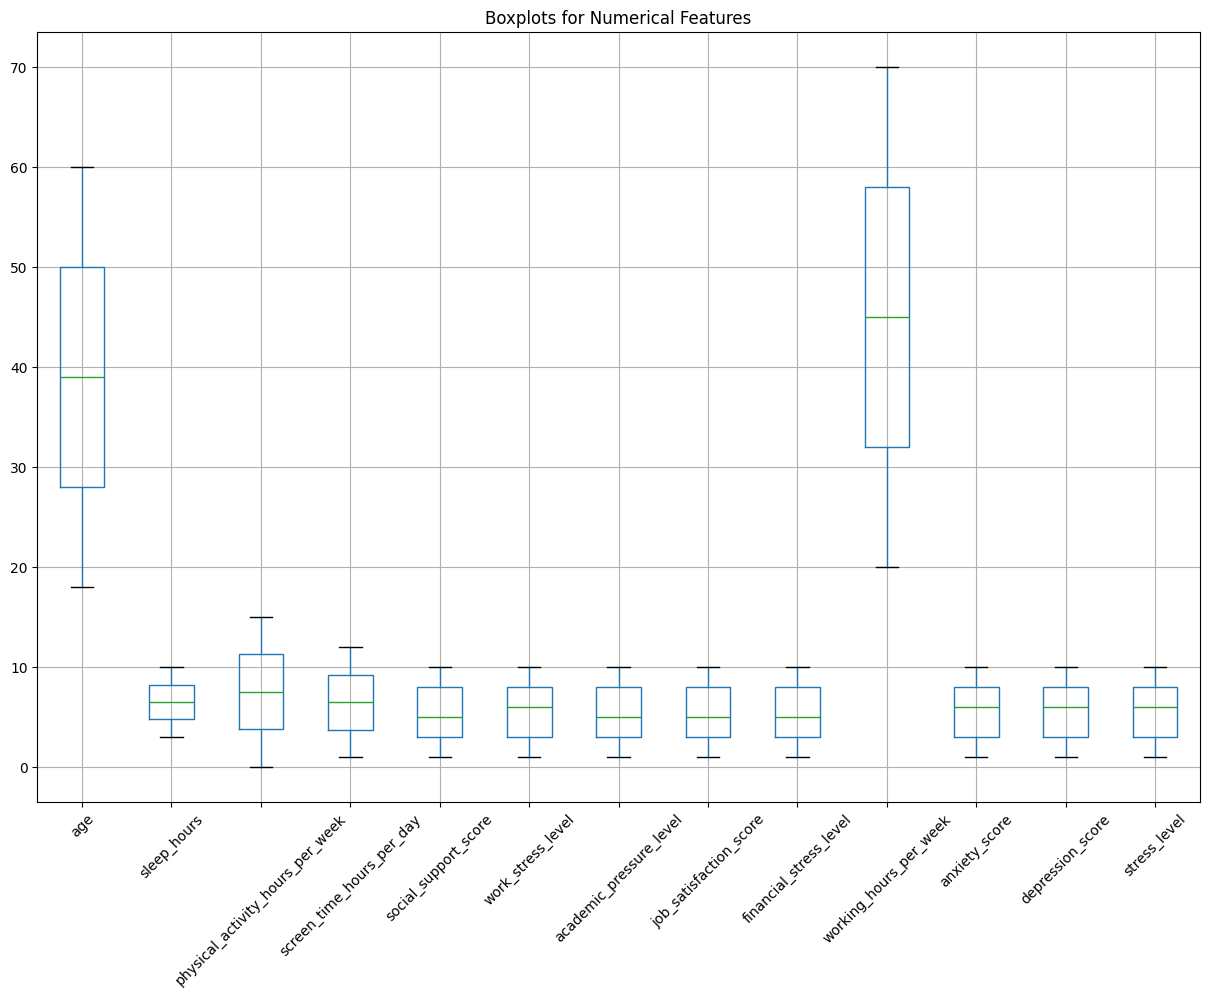

In [5]:
num_cols = [
    'age', 'sleep_hours', 'physical_activity_hours_per_week',
    'screen_time_hours_per_day', 'social_support_score',
    'work_stress_level', 'academic_pressure_level',
    'job_satisfaction_score', 'financial_stress_level',
    'working_hours_per_week', 'anxiety_score',
    'depression_score', 'stress_level'
]

plt.figure(figsize=(15,10))
df[num_cols].boxplot(rot=45)
plt.title("Boxplots for Numerical Features")
plt.show()

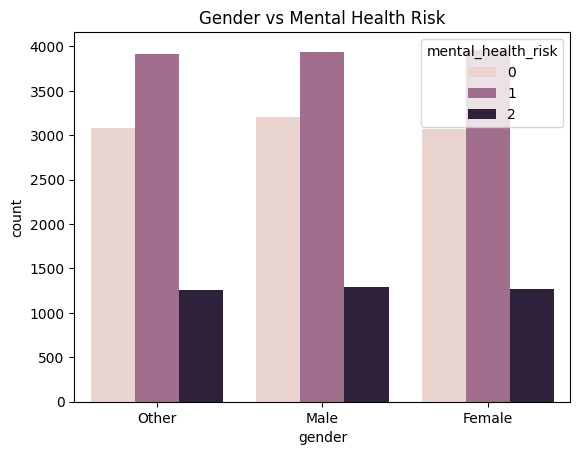

In [6]:
sns.countplot(x='gender', hue='mental_health_risk', data=df)
plt.title("Gender vs Mental Health Risk")
plt.show()

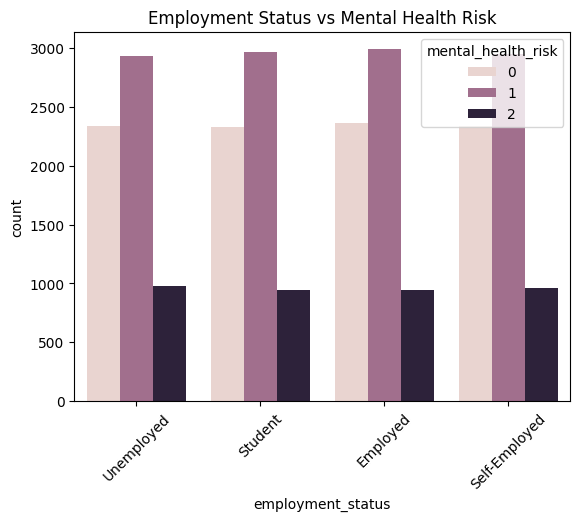

In [7]:
sns.countplot(x='employment_status', hue='mental_health_risk', data=df)
plt.xticks(rotation=45)
plt.title("Employment Status vs Mental Health Risk")
plt.show()

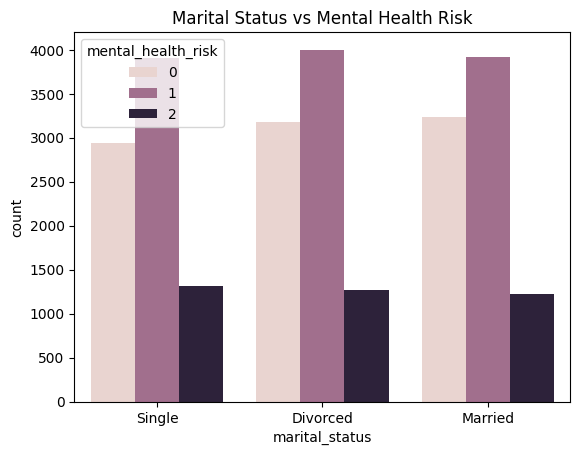

In [8]:
sns.countplot(x='marital_status', hue='mental_health_risk', data=df)
plt.title("Marital Status vs Mental Health Risk")
plt.show()

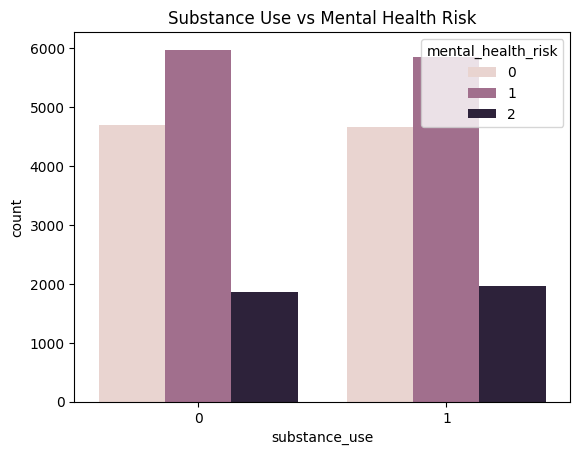

In [9]:
sns.countplot(x='substance_use', hue='mental_health_risk', data=df)
plt.title("Substance Use vs Mental Health Risk")
plt.show()

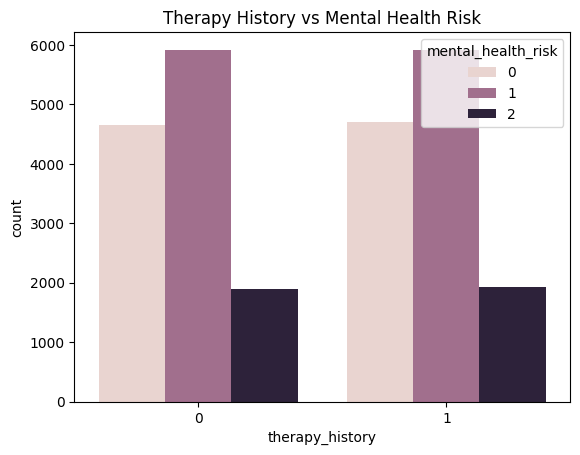

In [10]:
sns.countplot(x='therapy_history', hue='mental_health_risk', data=df)
plt.title("Therapy History vs Mental Health Risk")
plt.show()

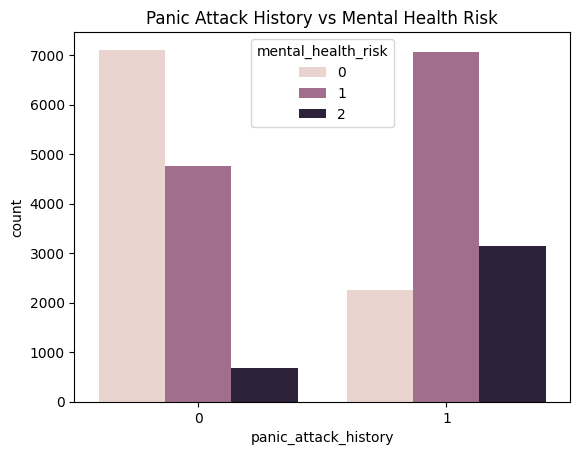

In [11]:
sns.countplot(x='panic_attack_history', hue='mental_health_risk', data=df)
plt.title("Panic Attack History vs Mental Health Risk")
plt.show()

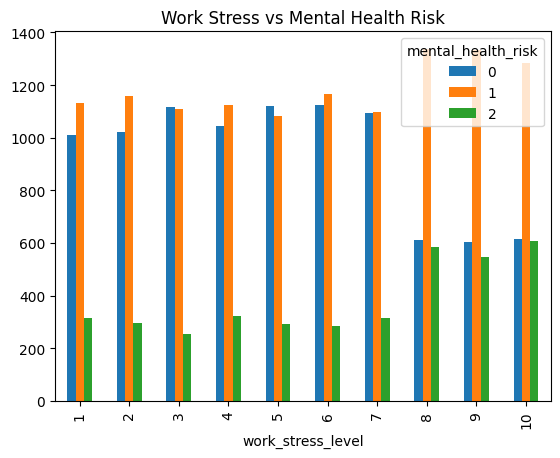

In [12]:
df.groupby('work_stress_level')['mental_health_risk'].value_counts().unstack().plot(kind='bar')
plt.title("Work Stress vs Mental Health Risk")
plt.show()

In [13]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

cat_cols = [
    'gender', 'marital_status', 'education_level',
    'employment_status', 'panic_attack_history',
    'family_history_mental_illness',
    'previous_mental_health_diagnosis',
    'therapy_history', 'substance_use'
]

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [14]:
#cat_cols = df.select_dtypes(include='object').columns
#print(cat_cols)
#from sklearn.preprocessing import LabelEncoder

#le = LabelEncoder()

#for col in cat_cols:
    #df[col] = le.fit_transform(df[col])
#

In [15]:
X = df.drop("mental_health_risk", axis=1)
y = df["mental_health_risk"]

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [33]:
print(df.dtypes)

age                                   int64
gender                                int64
marital_status                        int64
education_level                       int64
employment_status                     int64
sleep_hours                         float64
physical_activity_hours_per_week    float64
screen_time_hours_per_day           float64
social_support_score                  int64
work_stress_level                     int64
academic_pressure_level               int64
job_satisfaction_score                int64
financial_stress_level                int64
working_hours_per_week                int64
anxiety_score                         int64
depression_score                      int64
stress_level                          int64
mood_swings_frequency                 int64
concentration_difficulty_level        int64
panic_attack_history                  int64
family_history_mental_illness         int64
previous_mental_health_diagnosis      int64
therapy_history                 

In [34]:
lr = LogisticRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.7434


In [35]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.9934


In [36]:
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.9752


In [37]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))

KNN Accuracy: 0.6258


In [38]:
nb = GaussianNB()
nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.7564


In [39]:
svm = SVC()
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

SVM Accuracy: 0.8174


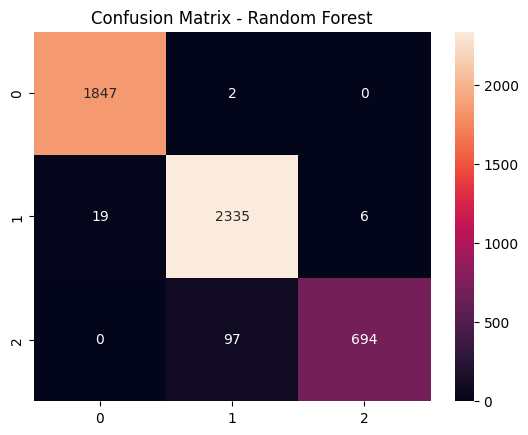

In [40]:
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Random Forest")
plt.show()

In [41]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1849
           1       0.96      0.99      0.97      2360
           2       0.99      0.88      0.93       791

    accuracy                           0.98      5000
   macro avg       0.98      0.96      0.97      5000
weighted avg       0.98      0.98      0.97      5000



In [42]:
results = {
    "Logistic Regression": accuracy_score(y_test, y_pred_lr),
    "Decision Tree": accuracy_score(y_test, y_pred_dt),
    "Random Forest": accuracy_score(y_test, y_pred_rf),
    "KNN": accuracy_score(y_test, y_pred_knn),
    "Naive Bayes": accuracy_score(y_test, y_pred_nb),
    "SVM": accuracy_score(y_test, y_pred_svm)
}

for model, acc in results.items():
    print(model, ":", acc)

Logistic Regression : 0.7434
Decision Tree : 0.9934
Random Forest : 0.9752
KNN : 0.6258
Naive Bayes : 0.7564
SVM : 0.8174


In [43]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10, 20]
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=5)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': 20, 'n_estimators': 100}
